In [1]:
# Load required libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load CIFAR10 dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

In [3]:
# Get shape of the data loaded
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

In [4]:
# Get class labels
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [5]:
# Reshape the y_train to 1-dimentional
y_train = y_train.reshape(-1, )

y_train.shape, y_train[0]

((50000,), 6)

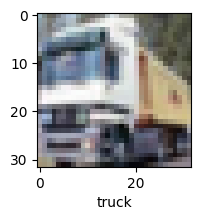

In [6]:
# Display random images to see how it looks
def plot_sample(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

plot_sample(X_train, y_train, 1)

In [7]:
# Normalize the train input data
X_train = X_train/255
X_test = X_test/255

X_train, X_test

(array([[[[0.23137255, 0.24313725, 0.24705882],
          [0.16862745, 0.18039216, 0.17647059],
          [0.19607843, 0.18823529, 0.16862745],
          ...,
          [0.61960784, 0.51764706, 0.42352941],
          [0.59607843, 0.49019608, 0.4       ],
          [0.58039216, 0.48627451, 0.40392157]],
 
         [[0.0627451 , 0.07843137, 0.07843137],
          [0.        , 0.        , 0.        ],
          [0.07058824, 0.03137255, 0.        ],
          ...,
          [0.48235294, 0.34509804, 0.21568627],
          [0.46666667, 0.3254902 , 0.19607843],
          [0.47843137, 0.34117647, 0.22352941]],
 
         [[0.09803922, 0.09411765, 0.08235294],
          [0.0627451 , 0.02745098, 0.        ],
          [0.19215686, 0.10588235, 0.03137255],
          ...,
          [0.4627451 , 0.32941176, 0.19607843],
          [0.47058824, 0.32941176, 0.19607843],
          [0.42745098, 0.28627451, 0.16470588]],
 
         ...,
 
         [[0.81568627, 0.66666667, 0.37647059],
          [0.78823

### Using Artificial Neural Network

In [8]:
# Train using Artificial Neural Network
ann = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='sigmoid')
])

ann.compile(optimizer='SGD',
           loss='sparse_categorical_crossentropy',
           metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=10)

C:\Users\Ciya\anaconda3\envs\dl_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.3066 - loss: 1.9299
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.4196 - loss: 1.6461
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.4499 - loss: 1.5561
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.4762 - loss: 1.4881
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.4947 - loss: 1.4372
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.5096 - loss: 1.3945
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.5264 - loss: 1.3470
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.5302 - loss: 1.3228
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.5484 - loss: 1.2799
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.5649 - loss: 1.2456


In [9]:
# Evaluate on test set
ann.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4657 - loss: 1.5427


[1.5545493364334106, 0.4603999853134155]

In [10]:
# Predict test results on trained model
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

y_pred_classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


[3,
 9,
 0,
 0,
 6,
 6,
 3,
 6,
 2,
 1,
 0,
 9,
 5,
 7,
 9,
 5,
 7,
 3,
 8,
 6,
 7,
 2,
 0,
 9,
 4,
 6,
 6,
 7,
 9,
 6,
 6,
 7,
 4,
 5,
 9,
 3,
 7,
 9,
 3,
 5,
 7,
 6,
 3,
 6,
 0,
 9,
 3,
 3,
 7,
 6,
 9,
 7,
 6,
 3,
 8,
 0,
 7,
 9,
 3,
 2,
 7,
 3,
 1,
 3,
 6,
 2,
 1,
 2,
 3,
 7,
 2,
 6,
 6,
 8,
 0,
 2,
 7,
 3,
 3,
 0,
 0,
 1,
 1,
 7,
 2,
 7,
 2,
 0,
 8,
 9,
 0,
 4,
 8,
 6,
 4,
 3,
 6,
 0,
 7,
 7,
 7,
 7,
 6,
 3,
 1,
 1,
 6,
 6,
 7,
 7,
 6,
 0,
 6,
 2,
 9,
 7,
 0,
 7,
 2,
 7,
 0,
 7,
 2,
 7,
 0,
 2,
 2,
 3,
 3,
 6,
 7,
 3,
 9,
 7,
 3,
 2,
 9,
 7,
 6,
 8,
 7,
 5,
 6,
 5,
 9,
 7,
 6,
 5,
 7,
 3,
 4,
 2,
 6,
 7,
 3,
 5,
 3,
 9,
 3,
 7,
 3,
 7,
 7,
 6,
 7,
 7,
 8,
 6,
 7,
 7,
 7,
 7,
 0,
 8,
 7,
 9,
 0,
 7,
 7,
 7,
 9,
 7,
 6,
 2,
 7,
 8,
 6,
 6,
 7,
 0,
 6,
 3,
 2,
 3,
 7,
 6,
 7,
 2,
 7,
 3,
 3,
 0,
 0,
 7,
 1,
 6,
 0,
 5,
 7,
 0,
 6,
 9,
 3,
 7,
 7,
 7,
 7,
 9,
 0,
 7,
 7,
 6,
 9,
 6,
 7,
 7,
 7,
 2,
 7,
 2,
 3,
 1,
 7,
 3,
 9,
 0,
 6,
 0,
 6,
 3,
 1,
 9,
 7,
 9,
 0,
 3,
 7,
 0,
 2,
 1,


In [11]:
# Caculate prediction accuracy
score = accuracy_score(y_test, y_pred_classes)
matrix = confusion_matrix(y_test, y_pred_classes)
report = classification_report(y_test, y_pred_classes)


print(score)
print(matrix)
print(report)

0.4604
[[583  14  84  57   7   2  45 163  22  23]
 [ 70 429  34 103   4  11  55 101  13 180]
 [ 58   7 383 128  16  29 183 189   3   4]
 [ 14   1  84 458  10  76 183 164   3   7]
 [ 31   1 161 100 145  18 269 264   5   6]
 [ 12   2 102 314  14 223 111 209   8   5]
 [  3   2  61  70  13  10 762  74   3   2]
 [ 16   1  40  72   7  15  40 801   1   7]
 [252  36  33  79   9  10  48 101 362  70]
 [ 62  65  21 122   1  10  62 193   6 458]]
              precision    recall  f1-score   support

           0       0.53      0.58      0.55      1000
           1       0.77      0.43      0.55      1000
           2       0.38      0.38      0.38      1000
           3       0.30      0.46      0.37      1000
           4       0.64      0.14      0.24      1000
           5       0.55      0.22      0.32      1000
           6       0.43      0.76      0.55      1000
           7       0.35      0.80      0.49      1000
           8       0.85      0.36      0.51      1000
           9       0.

### Since the prediction accuracy is poor, we are going to train the model with Convlutional Neural Network

In [12]:
# Train using Convolutional Neural Network
cnn = models.Sequential([
    # CNN
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    # Dense
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\Ciya\anaconda3\envs\dl_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Compile CNN model
cnn.compile(optimizer = 'adam',
             loss = 'sparse_categorical_crossentropy',
             metrics = ['accuracy'])

In [14]:
# Train the model
cnn.fit(X_train, y_train, epochs = 10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3928 - loss: 1.6720
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6029 - loss: 1.1281
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6594 - loss: 0.9840
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6878 - loss: 0.8965
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7122 - loss: 0.8188
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7340 - loss: 0.7651
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7543 - loss: 0.7163
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7722 - loss: 0.6578
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7860 - loss: 0.6206
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7974 - loss: 0.5750


In [15]:
# Evaluate on test set
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6893 - loss: 0.9508


[0.9629825353622437, 0.6873000264167786]

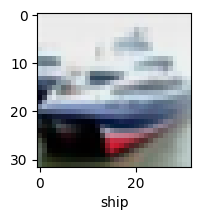

In [16]:
# Plot test data
y_test = y_test.reshape(-1,)
plot_sample(X_test, y_test, 1)

In [17]:
# Predict test results on trained model
y_pred = cnn.predict(X_test)
y_classes = [np.argmax(element) for element in y_pred]

y_classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


[3,
 1,
 1,
 0,
 4,
 6,
 1,
 6,
 3,
 1,
 4,
 9,
 5,
 7,
 9,
 6,
 5,
 7,
 8,
 6,
 7,
 2,
 4,
 9,
 4,
 2,
 4,
 0,
 9,
 6,
 6,
 2,
 4,
 5,
 9,
 3,
 4,
 9,
 9,
 5,
 4,
 6,
 7,
 6,
 0,
 9,
 3,
 7,
 7,
 2,
 9,
 6,
 6,
 3,
 8,
 8,
 7,
 8,
 5,
 2,
 7,
 5,
 6,
 1,
 6,
 2,
 1,
 2,
 5,
 2,
 2,
 6,
 8,
 8,
 0,
 2,
 1,
 5,
 2,
 8,
 8,
 1,
 1,
 7,
 2,
 7,
 2,
 4,
 9,
 9,
 0,
 6,
 8,
 6,
 4,
 6,
 6,
 2,
 2,
 7,
 4,
 5,
 6,
 3,
 1,
 1,
 3,
 6,
 3,
 7,
 4,
 0,
 2,
 2,
 9,
 0,
 0,
 4,
 6,
 5,
 0,
 3,
 1,
 2,
 8,
 2,
 8,
 3,
 3,
 2,
 4,
 1,
 9,
 9,
 1,
 2,
 9,
 7,
 2,
 8,
 4,
 5,
 3,
 5,
 1,
 7,
 6,
 6,
 7,
 3,
 8,
 9,
 6,
 0,
 0,
 5,
 2,
 9,
 3,
 4,
 2,
 1,
 6,
 6,
 0,
 2,
 8,
 6,
 5,
 0,
 9,
 0,
 9,
 8,
 9,
 9,
 3,
 7,
 5,
 0,
 0,
 7,
 2,
 6,
 6,
 8,
 6,
 3,
 7,
 0,
 6,
 9,
 7,
 1,
 7,
 6,
 8,
 4,
 7,
 8,
 5,
 1,
 8,
 7,
 1,
 3,
 0,
 4,
 7,
 9,
 3,
 0,
 2,
 9,
 8,
 4,
 3,
 9,
 8,
 7,
 7,
 6,
 9,
 4,
 4,
 9,
 4,
 2,
 5,
 2,
 3,
 1,
 2,
 8,
 8,
 0,
 4,
 7,
 5,
 2,
 1,
 1,
 1,
 9,
 0,
 6,
 9,
 8,
 2,
 0,


Predicted Output: automobile 
Actual Output:


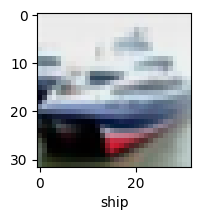

In [18]:
# Lets plot actual and predicted test sample for 2nd test item
plot_sample(X_test, y_test, 1)
print(f"Predicted Output: {classes[y_classes[1]]} \nActual Output:")

Predicted Output: deer 
Actual Output:


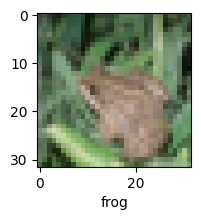

In [19]:
# Let's plot actual and predicted test sample for 5th test item
plot_sample(X_test, y_test, 4)
print(f"Predicted Output: {classes[y_classes[4]]} \nActual Output:")

In [20]:
# Calulate accuracy of predictions
score = accuracy_score(y_test, y_classes)
matrix = confusion_matrix(y_test, y_classes)
report = classification_report(y_test, y_classes)

print(score)
print(matrix)
print(report)

0.6873
[[707  30  86  17  41   5  20  19  36  39]
 [ 19 828  11   4   4   4   9   3  22  96]
 [ 43  13 661  23  99  36  71  35   8  11]
 [ 21  11 113 385 102 160 122  50   9  27]
 [ 10   6 113  24 654  24  94  62   8   5]
 [ 13  10 126 114  68 537  51  66   6   9]
 [  7   5  69  20  38  15 825  10   7   4]
 [ 12   6  52  18  78  40  14 759   4  17]
 [ 73  56  26  16  25   6  15   6 733  44]
 [ 30 100  16   5   8   6  14  20  17 784]]
              precision    recall  f1-score   support

           0       0.76      0.71      0.73      1000
           1       0.78      0.83      0.80      1000
           2       0.52      0.66      0.58      1000
           3       0.62      0.39      0.47      1000
           4       0.59      0.65      0.62      1000
           5       0.64      0.54      0.59      1000
           6       0.67      0.82      0.74      1000
           7       0.74      0.76      0.75      1000
           8       0.86      0.73      0.79      1000
           9       0.